# Recomendador de Sinopses - emblenddings reais com textos pequenos

Antes de carregar milhares de animes, vamos testar o processo com apenas algumas frases curtas. Isso nos permite verificar separadamente:

1. se conseguimos carregar um modelo de embeddings;
2. se textos semanticamente parecidos ficam próximos;
3. qual é o formato real dos vetores;
4. como o NumPy calcula a similaridade;
5. como visualizar um vetor com centenas de dimensões.

> Esta etapa já usa uma IA para gerar embeddings, mas ainda não usa um dataset grande, banco vetorial ou chatbot.
Antes de aplicarmos nossa técnica em um dataset gigante com milhares de sinopses de animes, precisamos garantir que o núcleo do nosso sistema funciona com textos curtos e reais. Para que o recomendador de animes "entenda" o que o usuário quer, usaremos a Similaridade do Cosseno. Essa métrica não compara as palavras exatas, mas sim a direção dos vetores no espaço multidimensional gerado pela IA. 


## Frases em emblenddings

In [8]:
from sentence_transformers import SentenceTransformer

modelo = SentenceTransformer(
    "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
)

frases = [
    "Uma aventura de fantasia em um mundo mágico.",
    "Uma jornada fantástica por um reino cheio de magia.",
    "Uma comédia escolar sobre amizade e música.",
    "Um grupo de heróis enfrenta monstros em uma longa jornada.",
]

embeddings = modelo.encode(frases)
 
print("Formatos dos embenddiings: ", embeddings.shape)

print("Primeiros 12 valores do primeiro embedding:")
print(embeddings[0][:12])

print("Tipo da matriz:", type(embeddings))
print("Tipo de um valor:", type(embeddings[0][0]))



Loading weights: 100%|██████████| 199/199 [00:00<00:00, 2366.51it/s]


Formatos dos embenddiings:  (4, 384)
Primeiros 12 valores do primeiro embedding:
[ 0.16176815  0.09984124 -0.26699555  0.18294364 -0.6823191  -0.4359224
  0.41151875 -0.24203688  0.04108814  0.17685072  0.47948417 -0.12003288]
Tipo da matriz: <class 'numpy.ndarray'>
Tipo de um valor: <class 'numpy.float32'>


#### O que esse codigo faz? 

##### Escopo inicial
O código começa preparando o terreno e executando a transformação matemática antes de exibir qualquer resultado na tela.

-  `modelo = SentenceTransformer(...)` :  Esta instrução instancia o modelo de linguagem pré-treinado na memória. O modelo especificado (paraphrase-multilingual-MiniLM-L12-v2) utiliza uma arquitetura baseada em Transformers, otimizada para processar múltiplos idiomas (incluindo o português) com alta eficiência computacional.

- `frases = [...]`:  É uma lista comum do Python contendo quatro textos com contextos diferentes.


- `embeddings = modelo.encode(frases)`: Representa a etapa de processamento principal. O método .encode() recebe as sentenças, realiza a tokenização e aplica os cálculos da rede neural para mapear os textos em um espaço vetorial. O resultado desse mapeamento é armazenado na variável embeddings.

Observação: O método `.encode()` preserva estritamente o mapeamento 1:1 da lista de entrada, vinculando o índice do texto original ao mesmo índice numérico na matriz gerada. A variável `embeddings` não é um vetor linear, mas uma matriz bidimensional (ex: 4 linhas/sentenças por 384 colunas/dimensões). Ao utilizar um único indexador estrutural, como `embeddings[1]`, a linguagem extrai a linha completa correspondente, entregando o vetor denso integral (todas as 384 coordenadas conjuntas) necessário para o cálculo direcional. O acesso a um ponto escalar isolado exigiria obrigatoriamente a indexação da segunda dimensão da matriz, como `embeddings[1][0]`. 
Ou seja embedding( Número de frases, Número de pontos do vetor) = (4, 384) isso significa que ela tem 4 linhas (frases) e 384 colunas (pontos do vetor).

##### Análise Estrutural (Função de cada print)

- `print("Formatos dos embenddiings: ", embeddings.shape)`: Extrai as dimensões exatas da matriz numérica gerada. O atributo .shape retornará a tupla (4, 384). O valor 4 corresponde ao tamanho do lote (batch size), refletindo as quatro frases de entrada. O valor 384 indica a dimensionalidade da representação vetorial. Isso confirma tecnicamente que cada frase foi convertida em um vetor de 384 coordenadas contínuas.

- `print(embeddings[0][:12])`: Acessa e exibe uma amostra transversal dos dados numéricos extraídos. Por meio do fatiamento em Python ([0][:12]), o comando isola o primeiro vetor (referente à primeira frase) e exibe apenas seus 12 primeiros escalares. O objetivo é inspecionar empiricamente as magnitudes numéricas (valores positivos e negativos) que quantificam as características semânticas do texto.

- `print("Tipo da matriz:", type(embeddings))`: Identifica a classe da estrutura de dados que armazena os embeddings. O retorno será <class 'numpy.ndarray'>. Isso demonstra que o método .encode() não gera uma lista nativa do Python, mas sim uma matriz multidimensional da biblioteca NumPy. Essa estrutura é fundamental para permitir operações de álgebra linear e processamento paralelo (essenciais para cálculos de similaridade, como a distância de cosseno).

- `print("Tipo de um valor:", type(embeddings[0][0]))`: Verifica a tipagem e a precisão de ponto flutuante de um único elemento dentro da matriz. O retorno será <class 'numpy.float32'>. Esta validação é crucial sob a ótica de engenharia de Machine Learning. Ela indica que a biblioteca alocou dados em precisão de 32 bits (em vez dos 64 bits padrão do Python), reduzindo pela metade o consumo de memória RAM. Este formato é o padrão exigido para aceleração em hardware (GPUs) e para indexação eficiente em bancos de dados vetoriais.


## Calculando a similaridade do cosseno

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 21993.85it/s]


[[1.    0.796 0.314 0.44 ]
 [0.796 1.    0.213 0.529]
 [0.314 0.213 1.    0.147]
 [0.44  0.529 0.147 1.   ]]


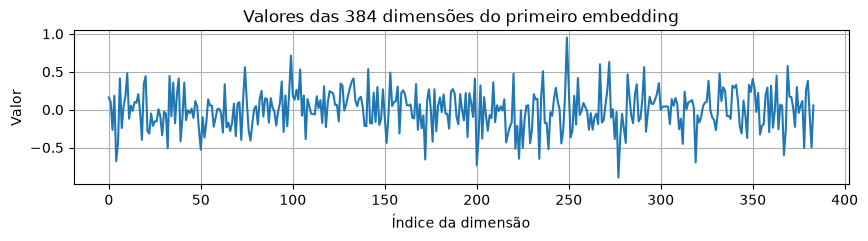

In [ ]:
import numpy as np
from sentence_transformers import SentenceTransformer
import matplotlib.pyplot as plt

def similaridadeCosseno(vetorA, vetorB):
    normA = np.linalg.norm(vetorA)
    normB = np.linalg.norm(vetorB)
    
    if normA == 0 or normB == 0:
        return 0.0
    
    produtoescalar = np.dot(vetorA,vetorB)
    return produtoescalar / (normA * normB)

modelo = SentenceTransformer(
    "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
)

frases = [
    "Uma aventura de fantasia em um mundo mágico.",
    "Uma jornada fantástica por um reino cheio de magia.",
    "Uma comédia escolar sobre amizade e música.",
    "Um grupo de heróis enfrenta monstros em uma longa jornada.",
]

embeddings = modelo.encode(frases)

quantidade_frases = len(frases)
matriz_similaridade = np.zeros((quantidade_frases, quantidade_frases))

for i in range(quantidade_frases):
    for j in range(quantidade_frases):
        matriz_similaridade[i][j] = similaridadeCosseno( embeddings[i], embeddings[j])

np.set_printoptions(precision=3, suppress=True)
print(matriz_similaridade)

plt.figure(figsize=(10, 2))
plt.plot(embeddings[0])

plt.title("Valores das 384 dimensões do primeiro embedding")
plt.xlabel("Índice da dimensão")
plt.ylabel("Valor")
plt.grid(True)

plt.show()


#### O que esse código faz?

##### Etapa de Automação e Pré-Alocação de Memória

- `(quantidade_frases = len(frases))`: Automatiza a contagem dos elementos da matriz de entrada de texto. A função conta a quantidade de frases.

- `(np.zeros)`: Comando de pré-alocação de memória RAM. A função constrói instantaneamente a matriz necessária para cruzar todos os dados (essa funcao cria listas de zeros). Os zeros inseridos não possuem valor matemático analítico; atuam estritamente como marcação de espaço físico para otimizar o processamento do sistema operacional. 

##### Etapa de Processamento Cruzado e Atribuição

- `(for i... e for j...)`: Estruturação de laços de repetição aninhados que atuam como o motor de navegação da matriz. Eles controlam sequencialmente os índices de linhas e colunas, garantindo o cruzamento exaustivo de todos os vetores gerados pela rede neural(criam a matriz).

- `(matriz_similaridade[i][j] = ...)`: Operação de atribuição onde o valor provisório (zero) armazenado na coordenada específica da matriz é substituído pelo resultado definitivo da função de similaridade do cosseno. Inicialmente a matriz_similaridade é apenas a matriz vazia, e depois, recebe os valores da lista(quantidade_frases) por meio do for.

##### Etapa de Renderização Gráfica e Visualização Vetorial

- `Importação do Motor Gráfico (import matplotlib.pyplot as plt)`: Incorporação da biblioteca responsável por traduzir matrizes numéricas puras em representações geométricas e visuais na interface do sistema.

- `(plt.figure)`: Comando que gera a estrutura de base do gráfico na memória. O parâmetro de proporção (figsize) estabelece rigidamente as dimensões retangulares da área de renderização antes da inserção de qualquer dado.

- `(plt.plot(embeddings[0]))`: Instrução de extração e plotagem focada exclusivamente no primeiro vetor da lista. A ferramenta lê a sequência de 384 números, atribuindo os índices estruturais ao eixo das abscissas (horizontal) e os valores gerados pela inteligência artificial ao eixo das ordenadas (vertical), unindo as coordenadas em um sinal contínuo(Transforma a frase[0] em gráfico).

- `(plt.title, plt.xlabel, plt.ylabel, plt.grid)`: Inserção de metadados descritivos nos eixos e ativação da malha de referência de fundo, estruturando a identificação técnica do espaço sem alterar os valores matemáticos.

- `(plt.show())`: Instrução de execução final que processa todos os parâmetros retidos no cache e obriga o sistema a compilar e exibir a janela gráfica consolidada.




## Usando norma em vez da similaridade do cosseno

In [15]:
import numpy as np
from sentence_transformers import SentenceTransformer

modelo = SentenceTransformer(
    "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
)

frases = [
    "Uma aventura de fantasia em um mundo mágico.",
    "Uma jornada fantástica por um reino cheio de magia.",
    "Uma comédia escolar sobre amizade e música.",
    "Um grupo de heróis enfrenta monstros em uma longa jornada.",
]

embeddings = modelo.encode(frases, normalize_embeddings=True,)

quantidade_frases = len(frases)
matriz_similaridade = np.zeros((quantidade_frases, quantidade_frases))

for i in range(quantidade_frases):
    for j in range(quantidade_frases):
        matriz_similaridade[i][j] = similaridade = np.dot(embeddings[0], embeddings[1])

np.set_printoptions(precision=3, suppress=True)
print(matriz_similaridade)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 9760.81it/s]


[[0.796 0.796 0.796 0.796]
 [0.796 0.796 0.796 0.796]
 [0.796 0.796 0.796 0.796]
 [0.796 0.796 0.796 0.796]]
